# Credit Card Fraud Detection using Machine Learning

This project aims to detect fraudulent credit card transactions using machine learning techniques. Fraud detection is a critical problem in financial technology (FinTech) because fraudulent activities can lead to significant financial losses.

Machine learning models implemented in this project include:

- Logistic Regression
- Random Forest
- XGBoost

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Description

The dataset contains credit card transactions made by European cardholders.

Key characteristics of the dataset:

- Total transactions: 284,807
- Fraudulent transactions: 492
- Fraud ratio: ~0.17%

Because fraud cases are extremely rare, this dataset represents a highly imbalanced classification problem.

In [16]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
df.shape

(284807, 31)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [19]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) was conducted to understand the structure of the dataset and the distribution of fraudulent transactions.

Visualizations help reveal patterns that may differentiate fraudulent activity from normal transactions.

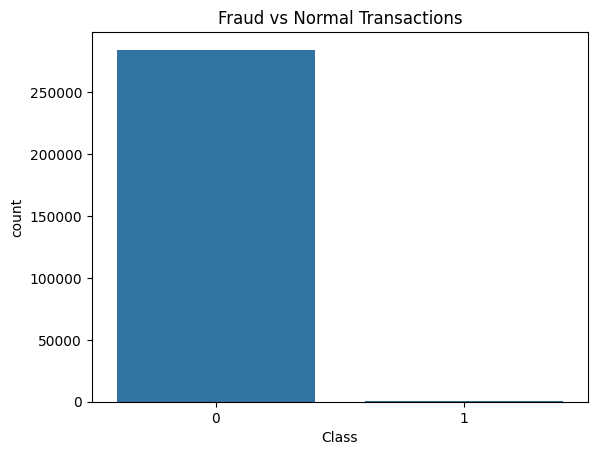

In [20]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

In [21]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

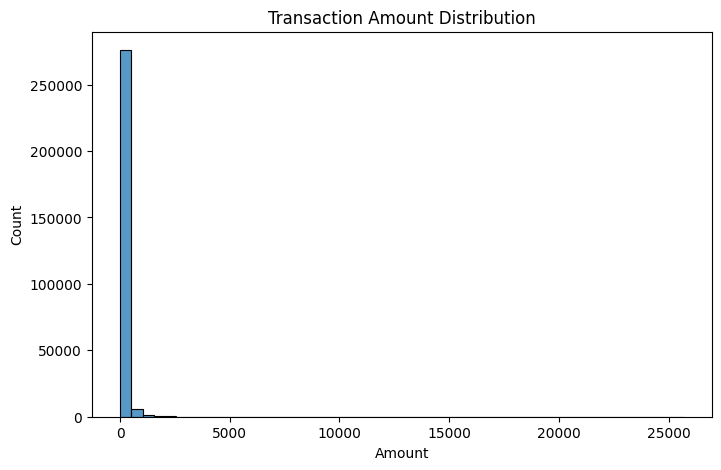

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

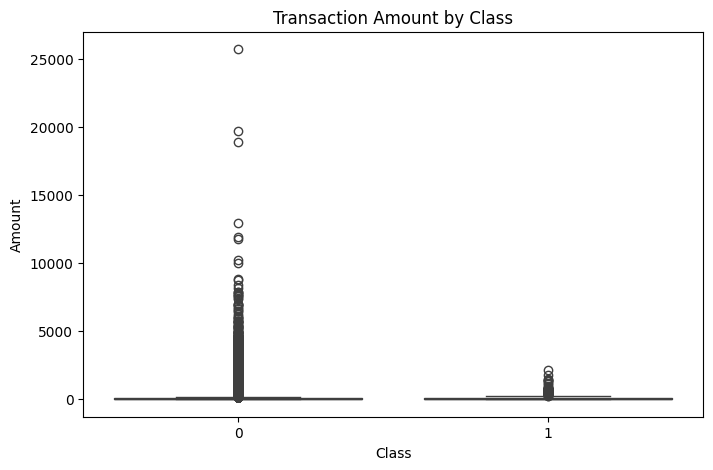

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

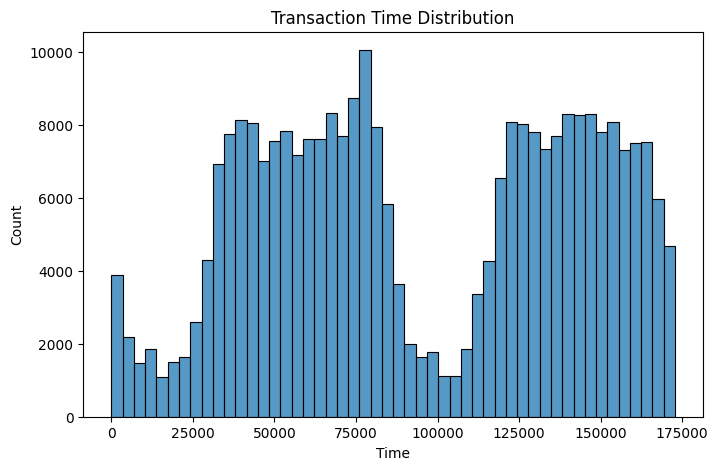

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()

## Feature Engineering

Feature engineering was applied to improve model performance.

A log transformation was applied to the transaction amount to reduce skewness:

log_amount = log(Amount + 1)

In [25]:
df["log_amount"] = np.log1p(df["Amount"])
df[["Amount", "log_amount"]].head()

,Amount,log_amount
0,149.62,5.014760
1,2.69,1.305626
2,378.66,5.939276
3,123.50,4.824306
4,69.99,4.262539


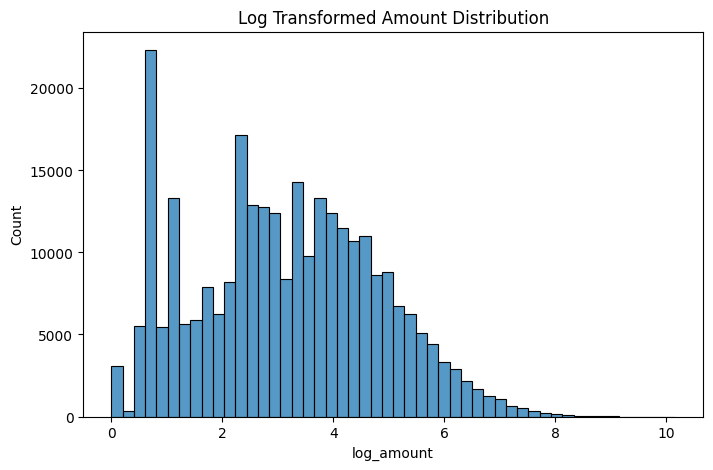

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df["log_amount"], bins=50)
plt.title("Log Transformed Amount Distribution")
plt.xlabel("log_amount")
plt.ylabel("Count")
plt.show()

In [27]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
X_train.shape, X_test.shape

((227845, 31), (56962, 31))

In [30]:
y_train.value_counts()

Class
0    227451
1       394
Name: count, dtype: int64

## Handling Imbalanced Data

Fraud datasets are highly imbalanced, meaning fraudulent transactions are extremely rare.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the training data by generating synthetic examples of the minority class.

In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [32]:
pd.Series(y_train_resampled).value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

## Machine Learning Models

Three machine learning models were implemented to detect fraudulent transactions:

- Logistic Regression
- Random Forest
- XGBoost

Model performance was evaluated using confusion matrix, classification report, and ROC-AUC score.

In [34]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, lr_prob))

Confusion Matrix:
[[56290   574]
 [   10    88]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962


ROC AUC Score:
0.9765156642989217


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [40]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, rf_prob))

Confusion Matrix:
[[56849    15]
 [   16    82]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962


ROC AUC Score:
0.9738879302424401


In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_resampled, y_train_resampled)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [42]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [43]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

print("\nROC AUC Score:")
print(roc_auc_score(y_test, xgb_prob))

Confusion Matrix:
[[56838    26]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.88      0.82        98

    accuracy                           1.00     56962
   macro avg       0.88      0.94      0.91     56962
weighted avg       1.00      1.00      1.00     56962


ROC AUC Score:
0.982941576321018


## Model Performance Comparison

In this section, the performance of each machine learning model is compared using ROC-AUC score.  
ROC-AUC is a critical metric for fraud detection because it measures how well the model distinguishes fraudulent transactions from legitimate ones.

In [44]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]

roc_scores = [
    roc_auc_score(y_test, lr_prob),
    roc_auc_score(y_test, rf_prob),
    roc_auc_score(y_test, xgb_prob)
]

comparison = pd.DataFrame({
    "Model": models,
    "ROC_AUC": roc_scores
})

comparison

,Model,ROC_AUC
0,Logistic Regression,0.976516
1,Random Forest,0.973888
2,XGBoost,0.982942


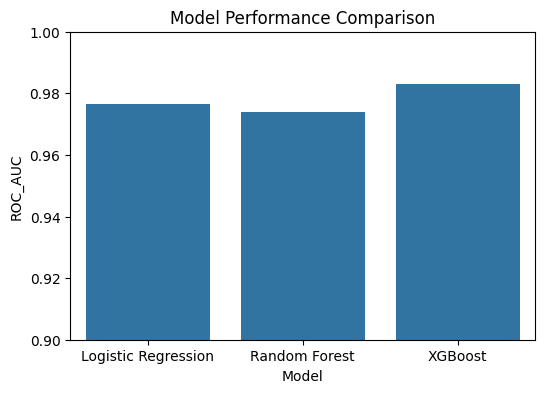

In [45]:
plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="ROC_AUC", data=comparison)
plt.title("Model Performance Comparison")
plt.ylim(0.9,1)
plt.show()

## Feature Importance Analysis

Feature importance analysis helps identify which variables contribute the most to fraud detection.  
Understanding these features provides insight into patterns that may indicate fraudulent behavior.

In [46]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

V14    0.213356
V10    0.158654
V4     0.116463
V12    0.090374
V17    0.073818
V11    0.072885
V3     0.056300
V7     0.028558
V16    0.028507
V2     0.024713
dtype: float64

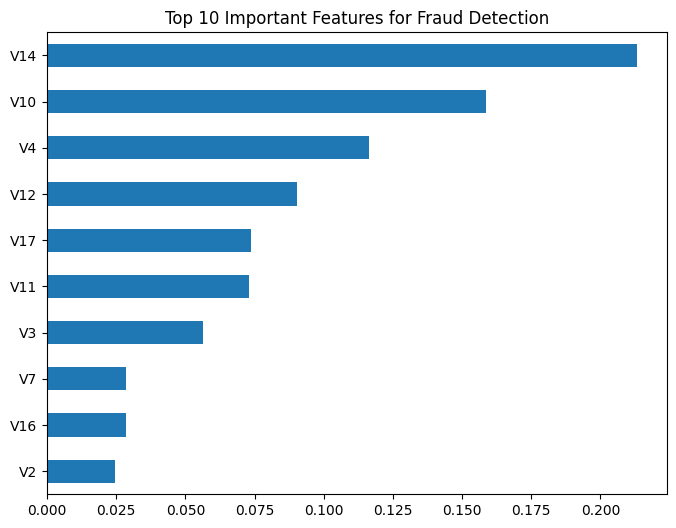

In [47]:
plt.figure(figsize=(8,6))
feature_importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features for Fraud Detection")
plt.gca().invert_yaxis()
plt.show()

## Key Insights

Several important insights were observed from the fraud detection analysis:

1. **Fraud transactions are extremely rare but highly impactful**  
   Fraudulent transactions represent less than 1% of the dataset. This extreme imbalance highlights why traditional accuracy metrics are not sufficient for fraud detection systems.

2. **Machine learning significantly improves fraud detection capability**  
   By applying machine learning models, the system was able to identify the majority of fraudulent transactions. The use of SMOTE helped the model better learn patterns associated with fraud cases.

3. **Ensemble models perform better in complex fraud patterns**  
   Models such as Random Forest and XGBoost demonstrated stronger performance compared to Logistic Regression, indicating that ensemble methods are better at capturing complex nonlinear relationships in transaction data.

4. **Early fraud detection can reduce financial risk**  
   Detecting fraudulent transactions in real time allows financial institutions to prevent potential losses and protect both customers and payment platforms.

5. **Feature importance analysis provides valuable behavioral signals**  
   The most influential features identified by the model may reflect hidden behavioral patterns associated with fraudulent transactions, which can be further investigated by fraud risk teams.

## Conclusion

This project demonstrates how machine learning can be applied to detect fraudulent credit card transactions in a highly imbalanced dataset.

By combining exploratory data analysis, feature engineering, SMOTE resampling, and multiple machine learning algorithms, the system achieved strong fraud detection performance with a high ROC-AUC score.

Among the evaluated models, ensemble algorithms such as Random Forest and XGBoost showed the strongest ability to distinguish fraudulent transactions from legitimate ones.

From a business perspective, implementing machine learning-based fraud detection systems can significantly improve financial risk monitoring and help organizations proactively prevent fraudulent activities.

Such systems are particularly valuable in digital payment platforms and fintech ecosystems, where millions of transactions occur daily and early detection is critical to minimizing financial losses and maintaining user trust.